In [ ]:
#Project Title & Objective
# Laptop Price Prediction and Analysis
# Objective:
# 1. Perform Exploratory Data Analysis (EDA)
# 2. Identify factors affecting laptop prices
# 3. Build ML models to predict price
# 4. Compare model performance


In [ ]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [ ]:
#Load Dataset
df = pd.read_csv('/content/laptop_data.csv.csv')  # upload to Colab
df.head()


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
#Basic Dataset Inspection
df.shape


(1303, 12)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [ ]:
df.isnull().sum()


,0
Unnamed: 0,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


In [ ]:
#Statistical Summary
df.describe()


,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


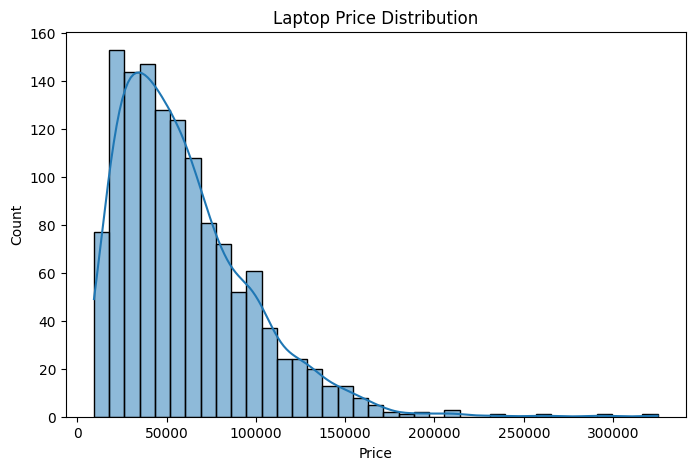

In [ ]:
#EXPLORATORY DATA ANALYSIS (EDA)
#Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], kde=True)
plt.title('Laptop Price Distribution')
plt.show()

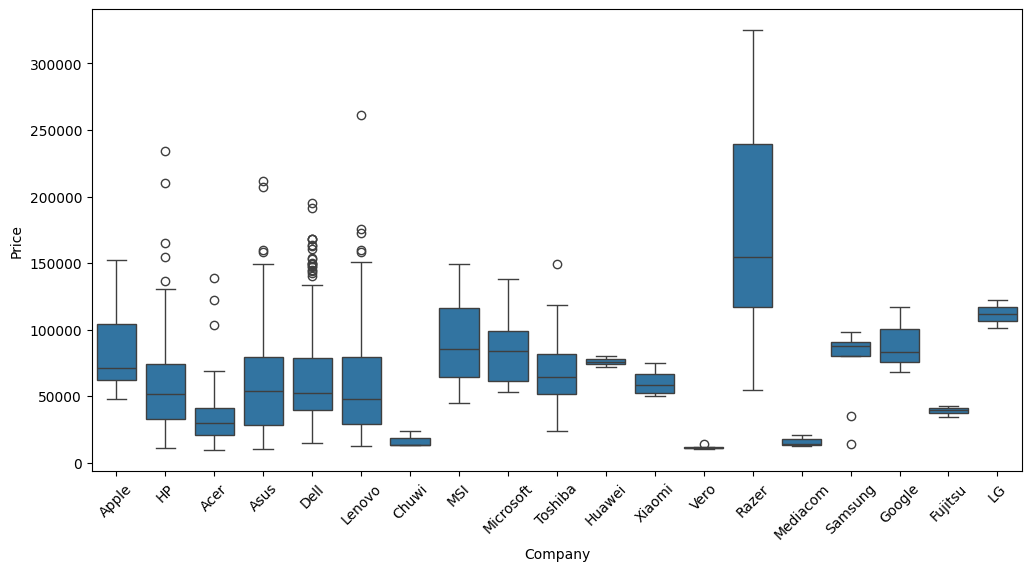

In [ ]:
#Company vs Price (Boxplot)
plt.figure(figsize=(12,6))
sns.boxplot(x='Company', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()

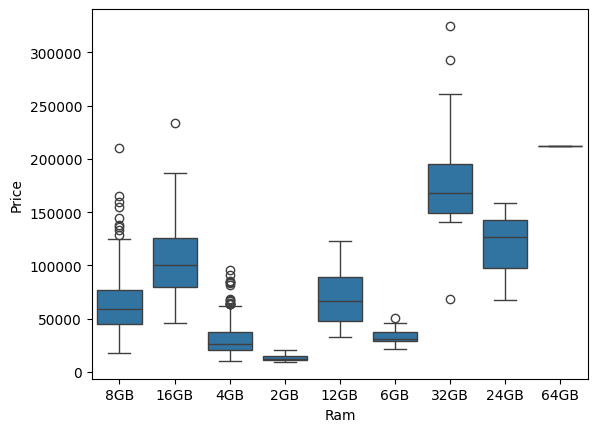

In [ ]:
#RAM vs Price
sns.boxplot(x='Ram', y='Price', data=df)
plt.show()


In [ ]:
#Touchscreen Pie Chart (Moved to after 'Touchscreen' column creation)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

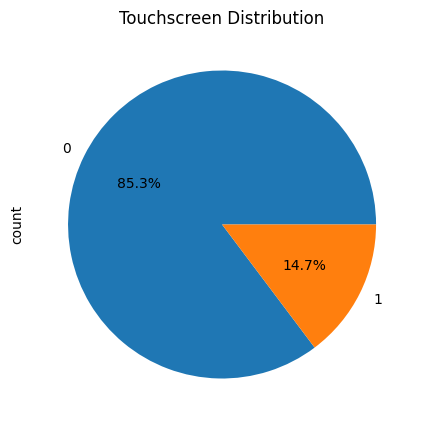

In [ ]:
# Extracting Touchscreen information
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df.head()

#Touchscreen Pie Chart
df['Touchscreen'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', figsize=(5,5)
)
plt.title('Touchscreen Distribution')
plt.show()

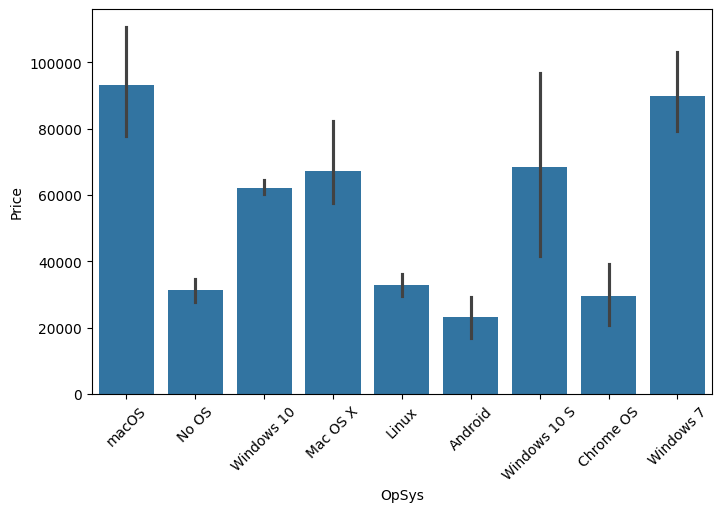

In [ ]:
#OS vs Price
plt.figure(figsize=(8,5))
sns.barplot(x='OpSys', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()

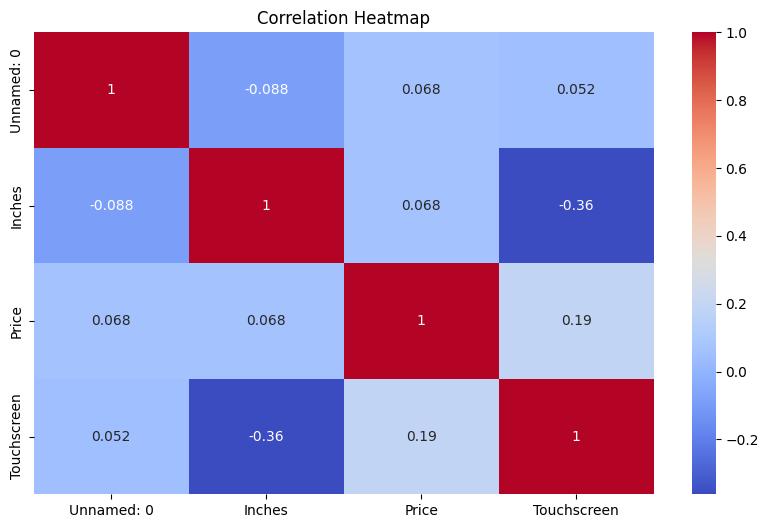

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
#FEATURE ENGINEERING
#Separate Features & Target
X = df.drop('Price', axis=1)
y = df['Price']


In [ ]:
#identify Categorical & Numerical Columns
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns


In [ ]:
#Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)


In [ ]:
#MODEL BUILDING
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
#Linear Regression Model
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Unnamed: 0', 'Inches', 'Touchscreen'], dtype='object'))])),
                ('model', LinearRegression())])

In [ ]:
#Linear Regression Evaluation
y_pred_lr = lr_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


R2 Score: 0.8468578473183692
MAE: 10001.4459235484
RMSE: 14859.768254844195
R2 Score: 0.8468578473183692
MAE: 10001.4459235484
RMSE: 14859.768254844195


In [ ]:
#Random Forest Model
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Unnamed: 0', 'Inches', 'Touchscreen'], dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [ ]:
#Random Forest Evaluation
y_pred_rf = rf_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


R2 Score: 0.7383016119868844
MAE: 10244.778570482757
RMSE: 19425.186021175312


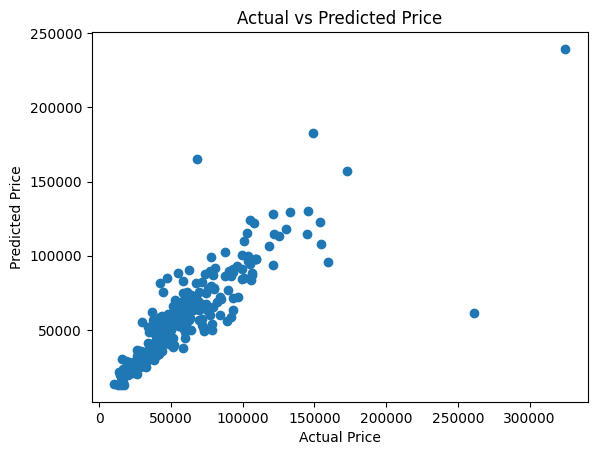

In [ ]:
#Actual vs Predicted Graph
plt.scatter(y_test, y_pred_rf)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()


In [ ]:
!pip install xgboost


In [ ]:
from xgboost import XGBRegressor


In [ ]:
#XGBoost Model Pipeline
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])


In [ ]:
xgb_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Unnamed: 0', 'Inches', 'Touchscreen'], dtype='object'))])),
                ('model',
                 XGBRegressor(base_score=None, booster=N...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
y_pred_xgb = xgb_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


R2 Score: 0.7966948752914206
MAE: 10095.439834997604
RMSE: 17121.382340349577


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2 Score': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

results


,Model,R2 Score,RMSE
0,Linear Regression,0.846858,14859.768255
1,Random Forest,0.738302,19425.186021
2,XGBoost,0.796695,17121.382340


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor


In [ ]:
gbr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gbr_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
       'Gpu', 'OpSys', 'Weight'],
      dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Unnamed: 0', 'Inches', 'Touchscreen'], dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(n_estimators=200, random_state=42))])

In [ ]:
#Gradient Boosting
y_pred_gbr = gbr_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))


R2: 0.8126931860992571
RMSE: 16433.930687383974


In [ ]:
xgb = xgb_model.named_steps['model']
feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

importance


,Feature,Importance
22,cat__TypeName_Notebook,0.100387
171,cat__Ram_4GB,0.054417
170,cat__Ram_32GB,0.046742
167,cat__Ram_16GB,0.044595
169,cat__Ram_2GB,0.025379
92,cat__Cpu_Intel Celeron Dual Core N3060 1.6GHz,0.022468
493,num__Inches,0.022161
24,cat__TypeName_Workstation,0.017686
100,cat__Cpu_Intel Core M 6Y30 0.9GHz,0.017131
283,cat__Gpu_Nvidia GeForce GTX 1070,0.015864


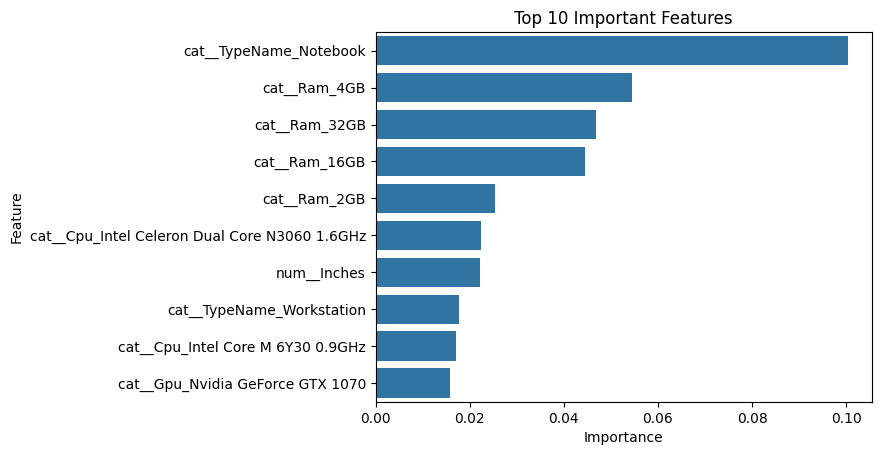

In [ ]:
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Top 10 Important Features')
plt.show()


In [ ]:
df['LogPrice'] = np.log1p(df['Price'])


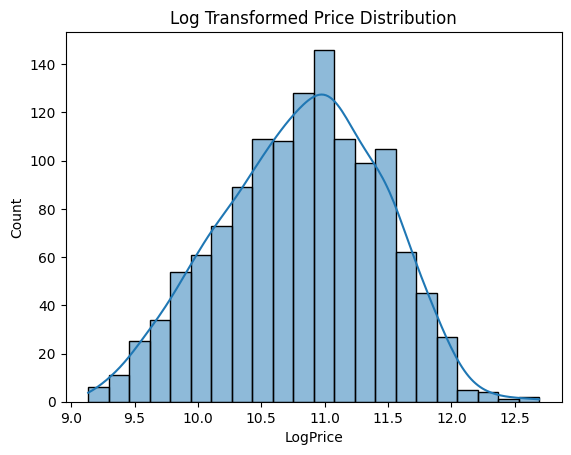

In [ ]:
sns.histplot(df['LogPrice'], kde=True)
plt.title('Log Transformed Price Distribution')
plt.show()


In [ ]:
df['Price_Category'] = pd.cut(
    df['Price'],
    bins=[0, 700, 1500, 7000],
    labels=['Budget', 'Mid-Range', 'Premium']
)


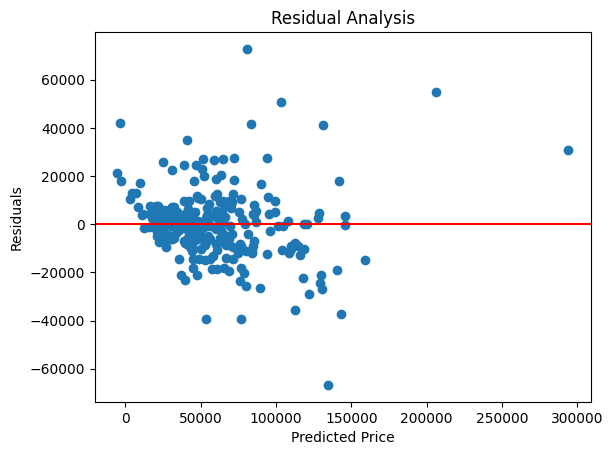

In [ ]:
#Residual Plot
residuals = y_test - y_pred_lr

plt.scatter(y_pred_lr, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()


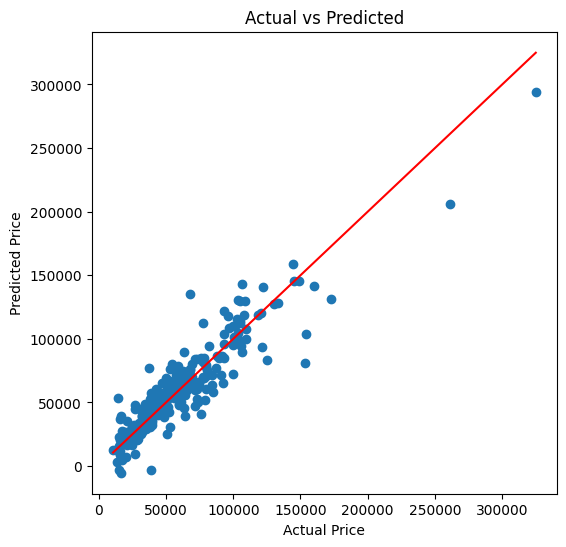

In [ ]:
#Actual vs Predicted Line Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()


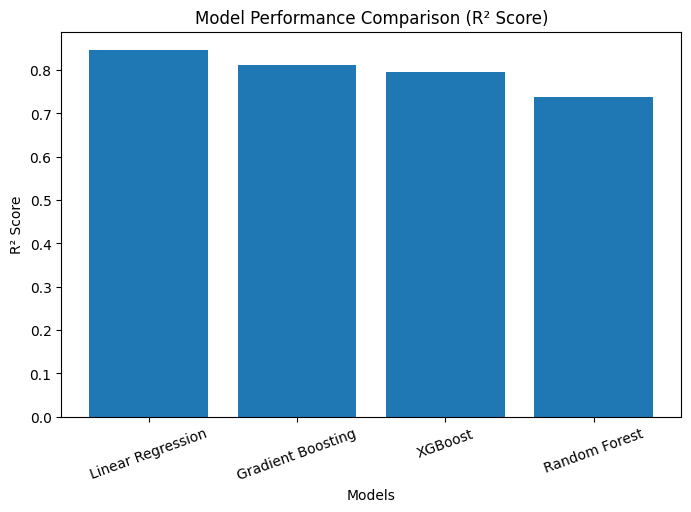

In [ ]:
import matplotlib.pyplot as plt

# Model names and R2 scores
models = ['Linear Regression', 'Gradient Boosting', 'XGBoost', 'Random Forest']
r2_scores = [0.8469, 0.8127, 0.7967, 0.7383]

plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

plt.title("Model Performance Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.xticks(rotation=20)
plt.show()

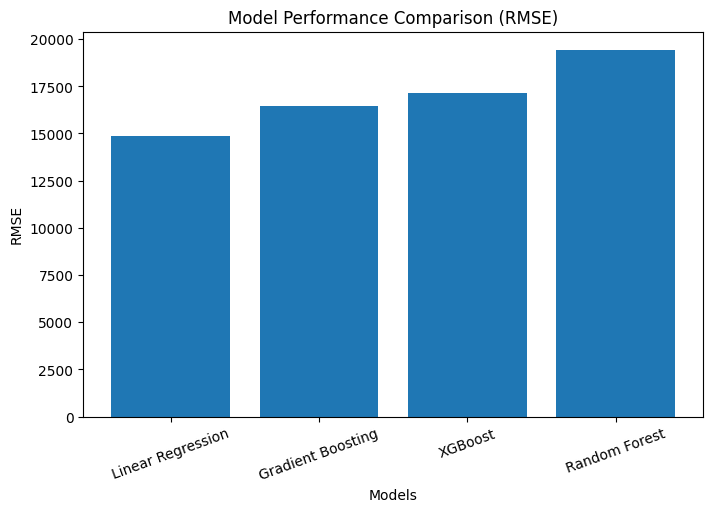

In [ ]:
rmse = [14859, 16433, 17121, 19425]

plt.figure(figsize=(8,5))
plt.bar(models, rmse)

plt.title("Model Performance Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=20)
plt.show()